# Comparative analysis of simulations set 1

Configuration:
- 60 days
- only SecondaryFollow
- probability of secondary follow = 0.25
- the same population for all simulations

In [1]:
from social_graph.analysis import add_behavioral_features_to_persona_summary
from social_graph.pipeline import *
from social_graph.metrics import *
from social_graph.describe import compare_persona_across_simulations

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\magda\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
conn3 = sqlite3.connect("data/exp_set_1/database_server_3.db")
conn4 = sqlite3.connect("data/exp_set_1/database_server_4.db")
conn5 = sqlite3.connect("data/exp_set_1/database_server_5.db")

connb1 = sqlite3.connect("data/exp_set_1/database_server_b1.db")
connb2 = sqlite3.connect("data/exp_set_1/database_server_b2.db")
connb3 = sqlite3.connect("data/exp_set_1/database_server_b3.db")

## Simulation b1

In [3]:
features_cols = ['openness', 'conscientiousness', 'extroversion', 'agreeableness', 'neuroticism']#, 'age', 'profession']

Running Simulation_b1...

Data loading ...

Number of users: 1000
Total actions: 16940
Follow actions: 12569
Unfollow actions: 4371
Number of rounds: 61
Number of posts: 138403

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 10)

Searching best number of persona ...

k=2 silhouette=0.1629
k=3 silhouette=0.1685
k=4 silhouette=0.1973
k=5 silhouette=0.2107
k=6 silhouette=0.2518
k=7 silhouette=0.2844
k=8 silhouette=0.3131
k=9 silhouette=0.3287


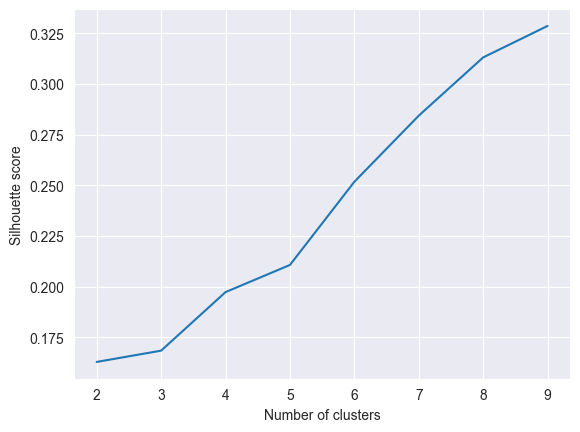


Done!


In [4]:
personaeb1, features_df_b1, followb1 = run_simulation_preprocessing(connb1, label='Simulation_b1', feature_cols=features_cols)

Running Simulation_b1...

Persona creation ...

persona
Persona_1    236
Persona_5    170
Persona_6    169
Persona_3    167
Persona_4    135
Persona_2    123
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 3.386654046839392e-133
conscientiousness: 6.8211618035854e-70
extroversion: 3.1349622379837405e-99
agreeableness: 1.0584187252945227e-67
neuroticism: 4.159344986844566e-121


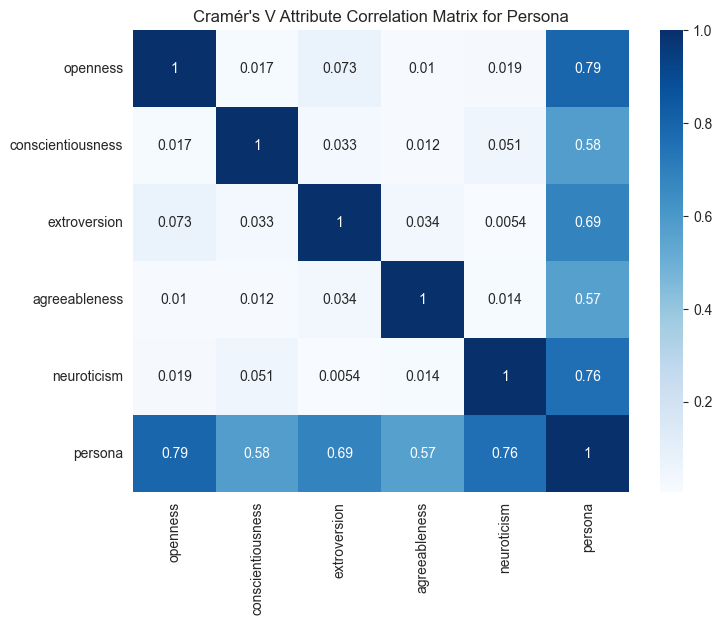

In [5]:
k_best = 6

description_b1, persona_dict = cluster_persona_and_analyse(personaeb1, features_df_b1, k_best, label='Simulation_b1', feature_cols=features_cols)

In [6]:
global_metrics_b1, summary_b1 = build_graph_and_analyse(followb1, persona_dict, label='Simulation_b1')

Running Simulation_b1...

Graph creation ...

Number of nodes: 888
Number of edges: 8211
Number of connective components: 8
Components sizes: [880, 1, 1, 1, 1, 1, 1, 2]
Number of nodes (LCC): 880
Number of edges (LCC): 8210

Global metrics ...

Mean degree: 18.49
Density: 0.0104
Diameter: 7
Avg. shortest path: 2.878
Modularity score: 0.179
Persona assortativity: -0.0003787544760508844

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.0496
out_degree statistics: p = 0.2412
total_degree statistics: p = 0.0981
betweenness statistics: p = 0.3624
eigenvector statistics: p = 0.0801
pagerank statistics: p = 0.1257
kcore statistics: p = 0.0581


In [7]:
summary_b1 = add_behavioral_features_to_persona_summary(connb1, summary_b1, personaeb1)
summary_b1

Invalid unfollow action for users 6 -> 825: unfollow
Invalid unfollow action for users 6 -> 825: unfollow
Invalid unfollow action for users 6 -> 843: unfollow
Invalid unfollow action for users 12 -> 377: unfollow
Invalid unfollow action for users 12 -> 646: unfollow
Invalid unfollow action for users 12 -> 934: unfollow
Invalid unfollow action for users 17 -> 2: unfollow
Invalid unfollow action for users 17 -> 174: unfollow
Invalid unfollow action for users 17 -> 187: unfollow
Invalid unfollow action for users 17 -> 341: unfollow
Invalid unfollow action for users 17 -> 400: unfollow
Invalid unfollow action for users 17 -> 400: unfollow
Invalid unfollow action for users 17 -> 679: unfollow
Invalid unfollow action for users 17 -> 825: unfollow
Invalid unfollow action for users 17 -> 825: unfollow
Invalid unfollow action for users 21 -> 58: unfollow
Invalid unfollow action for users 21 -> 485: unfollow
Invalid unfollow action for users 21 -> 485: unfollow
Invalid unfollow action for users 

C:\Users\magda\Studia\Master\src\social_graph\analysis.py:136: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  behavior_summary['lifespan_mean'].fillna(0, inplace=True)


,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio,Simulation,posts_per_day,avg_word_count,neutral_posts_ratio,negative_posts_ratio,survival_rate,lifespan_mean
persona,,,,,,,,,,,,,,,,
Persona_1,210,8.595238,8.552381,17.147619,0.001640,0.016416,0.001058,9.014286,0.930828,Simulation_b1,2.278265,33.340822,0.030822,0.048324,0.885752,4.324517
Persona_2,108,12.379630,11.018519,23.398148,0.002864,0.021241,0.001437,9.666667,1.264496,Simulation_b1,3.851852,33.253143,0.032148,0.044045,0.834017,4.844008
Persona_3,149,9.476510,9.973154,19.449664,0.001984,0.018460,0.001153,9.671141,1.014533,Simulation_b1,2.893144,32.491593,0.039659,0.051812,0.829620,3.884415
Persona_4,119,8.420168,8.571429,16.991597,0.001906,0.015283,0.001049,7.638655,0.923063,Simulation_b1,2.995525,32.505151,0.035457,0.055881,0.852508,4.616236
Persona_5,148,8.405405,8.405405,16.810811,0.001805,0.015682,0.001059,8.189189,0.931602,Simulation_b1,2.371618,33.326009,0.034490,0.052549,0.885185,3.540733
Persona_6,146,9.657534,10.095890,19.753425,0.002413,0.018290,0.001160,8.945205,1.021052,Simulation_b1,2.969608,33.235418,0.031939,0.046568,0.859336,4.082560


In [8]:
description_b1#.iloc[:,4:13]

,consistent/cautious,inventive/curious,efficient/organized,extravagant/careless,outgoing/energetic,solitary/reserved,critical/judgmental,friendly/compassionate,resilient/confident,sensitive/nervous
persona,,,,,,,,,,
Persona_1,0.233051,0.766949,0.368644,0.631356,0.898305,0.101695,0.148305,0.851695,0.724576,0.275424
Persona_2,1.000000,0.000000,0.219512,0.780488,1.000000,0.000000,0.756098,0.243902,0.268293,0.731707
Persona_3,1.000000,0.000000,0.586826,0.413174,0.167665,0.832335,0.568862,0.431138,1.000000,0.000000
Persona_4,0.229630,0.770370,0.000000,1.000000,0.274074,0.725926,0.785185,0.214815,0.000000,1.000000
Persona_5,0.800000,0.200000,0.776471,0.223529,0.147059,0.852941,0.217647,0.782353,0.000000,1.000000
Persona_6,0.000000,1.000000,0.857988,0.142012,0.372781,0.627219,0.828402,0.171598,0.692308,0.307692


## Simulation b2

Running Simulation_b2...

Data loading ...

Number of users: 1000
Total actions: 17434
Follow actions: 12977
Unfollow actions: 4457
Number of rounds: 61
Number of posts: 142953

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 10)

Searching best number of persona ...

k=2 silhouette=0.1629
k=3 silhouette=0.1685
k=4 silhouette=0.1973
k=5 silhouette=0.2107
k=6 silhouette=0.2518
k=7 silhouette=0.2844
k=8 silhouette=0.3131
k=9 silhouette=0.3287


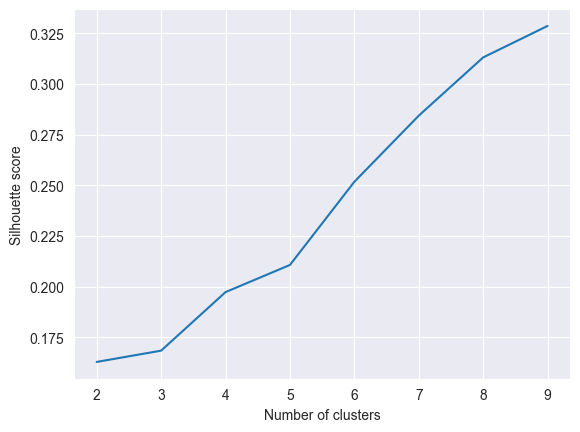


Done!


In [9]:
personaeb2, features_df_b2, followb2 = run_simulation_preprocessing(connb2, label='Simulation_b2', feature_cols=features_cols)

Running Simulation_b2...

Persona creation ...

persona
Persona_1    236
Persona_5    170
Persona_6    169
Persona_3    167
Persona_4    135
Persona_2    123
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 3.386654046839392e-133
conscientiousness: 6.8211618035854e-70
extroversion: 3.1349622379837405e-99
agreeableness: 1.0584187252945227e-67
neuroticism: 4.159344986844566e-121


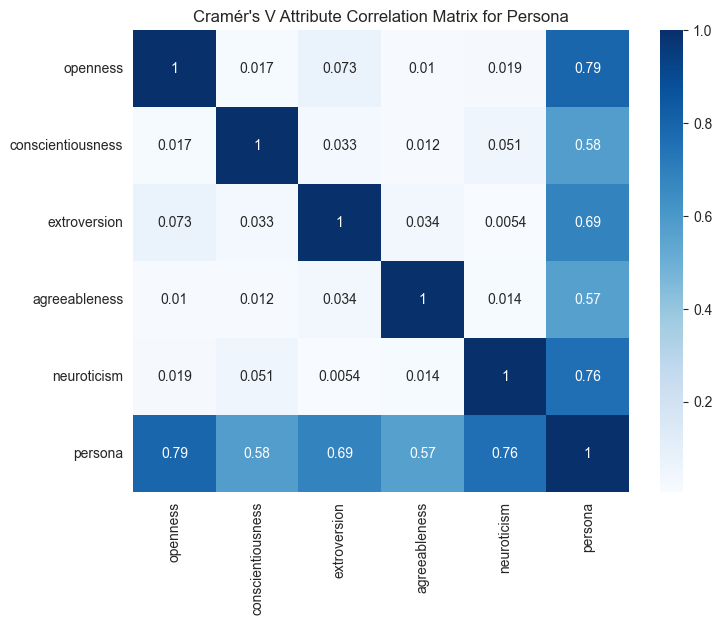

In [10]:
k_best = 6

description_b2, persona_dict = cluster_persona_and_analyse(personaeb2, features_df_b2, k_best, label='Simulation_b2', feature_cols=features_cols)

In [11]:
global_metrics_b2, summary_b2 = build_graph_and_analyse(followb2, persona_dict, label='Simulation_b2')

Running Simulation_b2...

Graph creation ...

Number of nodes: 895
Number of edges: 8593
Number of connective components: 14
Components sizes: [882, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Number of nodes (LCC): 882
Number of edges (LCC): 8593

Global metrics ...

Mean degree: 19.20
Density: 0.0107
Diameter: 7
Avg. shortest path: 2.864
Modularity score: 0.176
Persona assortativity: -0.00695443701067629

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.1042
out_degree statistics: p = 0.0699
total_degree statistics: p = 0.0524
betweenness statistics: p = 0.3081
eigenvector statistics: p = 0.0177
pagerank statistics: p = 0.0892
kcore statistics: p = 0.0380


In [12]:
summary_b2 = add_behavioral_features_to_persona_summary(connb2, summary_b2, personaeb2)
summary_b2

Invalid unfollow action for users 6 -> 233: unfollow
Invalid unfollow action for users 10 -> 767: unfollow
Invalid unfollow action for users 12 -> 58: unfollow
Invalid unfollow action for users 12 -> 802: unfollow
Invalid unfollow action for users 12 -> 843: unfollow
Invalid unfollow action for users 18 -> 700: unfollow
Invalid unfollow action for users 21 -> 679: unfollow
Invalid unfollow action for users 21 -> 825: unfollow
Invalid unfollow action for users 21 -> 914: unfollow
Invalid unfollow action for users 21 -> 914: unfollow
Invalid unfollow action for users 27 -> 280: unfollow
Invalid unfollow action for users 27 -> 400: unfollow
Invalid unfollow action for users 29 -> 190: unfollow
Invalid unfollow action for users 29 -> 934: unfollow
Invalid unfollow action for users 33 -> 900: unfollow
Invalid unfollow action for users 34 -> 276: unfollow
Invalid unfollow action for users 58 -> 198: unfollow
Invalid unfollow action for users 58 -> 198: unfollow
Invalid unfollow action for us

C:\Users\magda\Studia\Master\src\social_graph\analysis.py:136: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  behavior_summary['lifespan_mean'].fillna(0, inplace=True)


,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio,Simulation,posts_per_day,avg_word_count,neutral_posts_ratio,negative_posts_ratio,survival_rate,lifespan_mean
persona,,,,,,,,,,,,,,,,
Persona_1,207,8.144928,8.700483,16.845411,0.001335,0.016126,0.000984,9.338164,0.867942,Simulation_b2,2.278670,33.257555,0.032276,0.046727,0.883913,4.632091
Persona_2,107,13.962617,12.803738,26.766355,0.003058,0.023081,0.001539,10.943925,1.357632,Simulation_b2,4.126500,32.830690,0.035536,0.054285,0.830523,5.397628
Persona_3,156,9.480769,9.858974,19.339744,0.001752,0.017848,0.001093,9.692308,0.963936,Simulation_b2,2.860502,32.754783,0.039108,0.045426,0.855123,4.627082
Persona_4,115,8.913043,9.026087,17.939130,0.001865,0.015694,0.001059,7.965217,0.933995,Simulation_b2,2.993711,33.242484,0.038368,0.066430,0.879971,3.519540
Persona_5,145,9.206897,9.131034,18.337931,0.002017,0.015873,0.001075,8.558621,0.948011,Simulation_b2,2.778077,33.196129,0.039168,0.042487,0.864502,4.713461
Persona_6,152,10.355263,10.013158,20.368421,0.002051,0.018251,0.001207,9.638158,1.064634,Simulation_b2,2.970048,33.219771,0.035022,0.039481,0.862660,4.230289


## Simulation b3

Running Simulation_b3...

Data loading ...

Number of users: 1000
Total actions: 16690
Follow actions: 12468
Unfollow actions: 4222
Number of rounds: 61
Number of posts: 129708

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 10)

Searching best number of persona ...

k=2 silhouette=0.1629
k=3 silhouette=0.1685
k=4 silhouette=0.1973
k=5 silhouette=0.2107
k=6 silhouette=0.2518
k=7 silhouette=0.2844
k=8 silhouette=0.3131
k=9 silhouette=0.3287


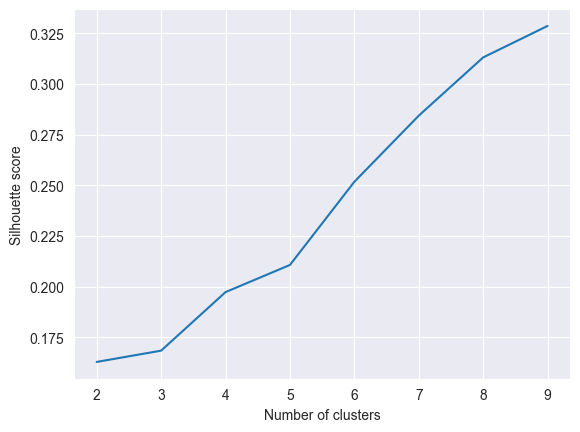


Done!


In [13]:
personaeb3, features_df_b3, followb3 = run_simulation_preprocessing(connb3, label='Simulation_b3', feature_cols=features_cols)

Running Simulation_b3...

Persona creation ...

persona
Persona_1    236
Persona_5    170
Persona_6    169
Persona_3    167
Persona_4    135
Persona_2    123
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 3.386654046839392e-133
conscientiousness: 6.8211618035854e-70
extroversion: 3.1349622379837405e-99
agreeableness: 1.0584187252945227e-67
neuroticism: 4.159344986844566e-121


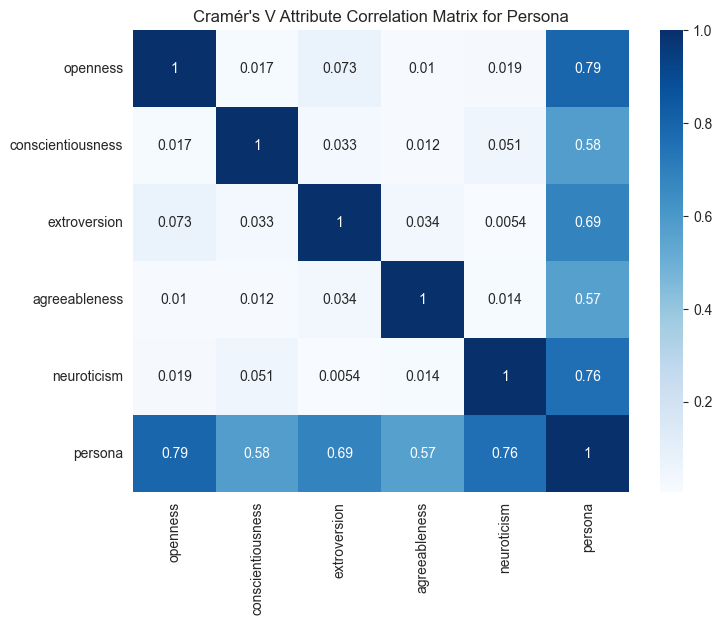

In [14]:
k_best = 6

description_b3, persona_dict = cluster_persona_and_analyse(personaeb3, features_df_b3, k_best, label='Simulation_b3', feature_cols=features_cols)

In [15]:
global_metrics_b3, summary_b3 = build_graph_and_analyse(followb3, persona_dict, label='Simulation_b3')

Running Simulation_b3...

Graph creation ...

Number of nodes: 891
Number of edges: 8278
Number of connective components: 4
Components sizes: [888, 1, 1, 1]
Number of nodes (LCC): 888
Number of edges (LCC): 8278

Global metrics ...

Mean degree: 18.58
Density: 0.0104
Diameter: 8
Avg. shortest path: 2.896
Modularity score: 0.185
Persona assortativity: -0.006705564988234148

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.8350
out_degree statistics: p = 0.9464
total_degree statistics: p = 0.9184
betweenness statistics: p = 0.7846
eigenvector statistics: p = 0.8342
pagerank statistics: p = 0.9270
kcore statistics: p = 0.8683


In [16]:
summary_b3 = add_behavioral_features_to_persona_summary(connb3, summary_b3, personaeb3)
summary_b3

Invalid unfollow action for users 8 -> 58: unfollow
Invalid unfollow action for users 8 -> 724: unfollow
Invalid unfollow action for users 12 -> 8: unfollow
Invalid unfollow action for users 12 -> 614: unfollow
Invalid unfollow action for users 12 -> 646: unfollow
Invalid unfollow action for users 12 -> 776: unfollow
Invalid unfollow action for users 13 -> 77: unfollow
Invalid unfollow action for users 17 -> 892: unfollow
Invalid unfollow action for users 17 -> 892: unfollow
Invalid unfollow action for users 21 -> 12: unfollow
Invalid unfollow action for users 21 -> 12: unfollow
Invalid unfollow action for users 21 -> 17: unfollow
Invalid unfollow action for users 21 -> 109: unfollow
Invalid unfollow action for users 21 -> 892: unfollow
Invalid unfollow action for users 21 -> 908: unfollow
Invalid unfollow action for users 22 -> 341: unfollow
Invalid unfollow action for users 22 -> 341: unfollow
Invalid unfollow action for users 27 -> 373: unfollow
Invalid unfollow action for users 27 

C:\Users\magda\Studia\Master\src\social_graph\analysis.py:136: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  behavior_summary['lifespan_mean'].fillna(0, inplace=True)


,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio,Simulation,posts_per_day,avg_word_count,neutral_posts_ratio,negative_posts_ratio,survival_rate,lifespan_mean
persona,,,,,,,,,,,,,,,,
Persona_1,216,9.226852,9.083333,18.310185,0.001964,0.017201,0.001119,9.078704,0.993666,Simulation_b3,2.450950,33.078720,0.036286,0.048983,0.865172,4.342591
Persona_2,111,11.441441,10.558559,22.000000,0.002440,0.020122,0.001320,9.612613,1.171838,Simulation_b3,3.018654,32.835755,0.037533,0.050768,0.863220,3.766361
Persona_3,152,8.361842,8.947368,17.309211,0.001676,0.016809,0.001027,9.243421,0.912411,Simulation_b3,2.410094,32.913773,0.039454,0.047245,0.873496,3.807890
Persona_4,112,7.651786,9.232143,16.883929,0.001867,0.016075,0.000967,8.562500,0.859104,Simulation_b3,2.612222,33.083694,0.042863,0.051008,0.865584,4.557488
Persona_5,150,8.960000,8.553333,17.513333,0.001890,0.016253,0.001105,8.526667,0.981133,Simulation_b3,2.334405,33.001392,0.030828,0.044467,0.849412,4.843202
Persona_6,147,10.496599,9.979592,20.476190,0.002381,0.018668,0.001235,9.156463,1.096721,Simulation_b3,2.968035,33.263179,0.036517,0.042230,0.871077,4.404290


## Simulation 3

Running Simulation_3...

Data loading ...

Number of users: 1000
Total actions: 16424
Follow actions: 12317
Unfollow actions: 4107
Number of rounds: 61
Number of posts: 134867

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 10)

Searching best number of persona ...

k=2 silhouette=0.1629
k=3 silhouette=0.1685
k=4 silhouette=0.1973
k=5 silhouette=0.2107
k=6 silhouette=0.2518
k=7 silhouette=0.2844
k=8 silhouette=0.3131
k=9 silhouette=0.3287


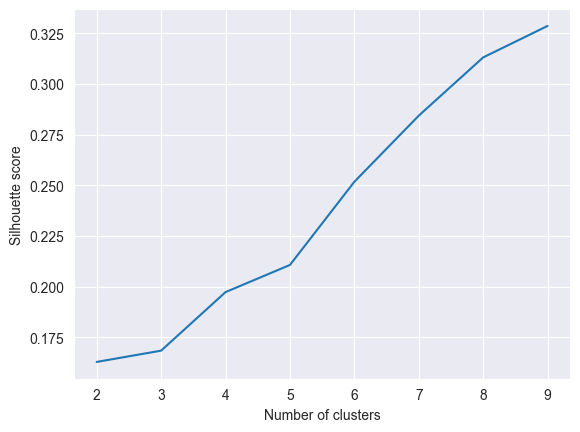


Done!


In [17]:
personae3, features_df_3, follow3 = run_simulation_preprocessing(conn3, label='Simulation_3', feature_cols=features_cols)

Running Simulation_3...

Persona creation ...

persona
Persona_1    236
Persona_5    170
Persona_6    169
Persona_3    167
Persona_4    135
Persona_2    123
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 3.386654046839392e-133
conscientiousness: 6.8211618035854e-70
extroversion: 3.1349622379837405e-99
agreeableness: 1.0584187252945227e-67
neuroticism: 4.159344986844566e-121


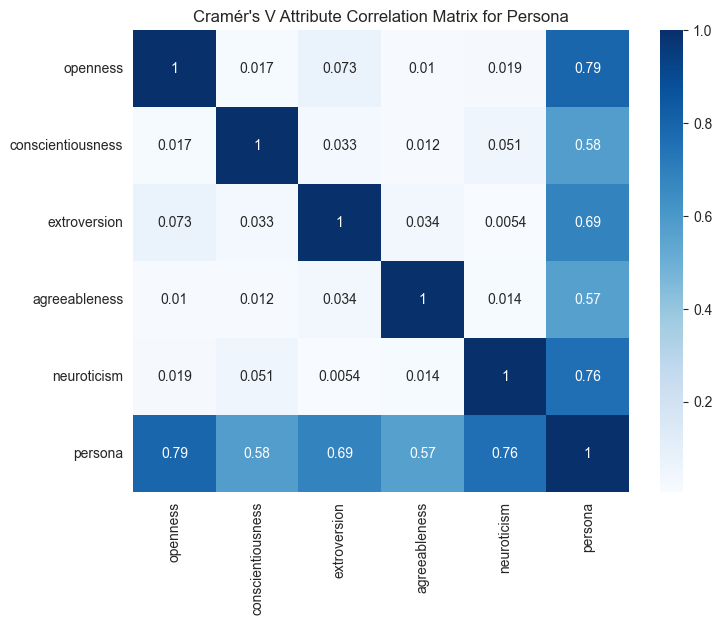

In [18]:
k_best = 6

description_3, persona_dict = cluster_persona_and_analyse(personae3, features_df_3, k_best, label='Simulation_3', feature_cols=features_cols)

In [19]:
global_metrics_3, summary_3 = build_graph_and_analyse(follow3, persona_dict, label='Simulation_3')

Running Simulation_3...

Graph creation ...

Number of nodes: 892
Number of edges: 8248
Number of connective components: 16
Components sizes: [877, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Number of nodes (LCC): 877
Number of edges (LCC): 8248

Global metrics ...

Mean degree: 18.49
Density: 0.0104
Diameter: 6
Avg. shortest path: 2.879
Modularity score: 0.174
Persona assortativity: -0.005899704804734914

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.7137
out_degree statistics: p = 0.7003
total_degree statistics: p = 0.7340
betweenness statistics: p = 0.8754
eigenvector statistics: p = 0.7391
pagerank statistics: p = 0.8538
kcore statistics: p = 0.7082


In [20]:
summary_3 = add_behavioral_features_to_persona_summary(conn3, summary_3, personae3)
summary_3

Invalid unfollow action for users 8 -> 342: unfollow
Invalid unfollow action for users 12 -> 333: unfollow
Invalid unfollow action for users 12 -> 679: unfollow
Invalid unfollow action for users 12 -> 690: unfollow
Invalid unfollow action for users 17 -> 32: unfollow
Invalid unfollow action for users 17 -> 323: unfollow
Invalid unfollow action for users 17 -> 341: unfollow
Invalid unfollow action for users 17 -> 500: unfollow
Invalid unfollow action for users 17 -> 914: unfollow
Invalid unfollow action for users 17 -> 934: unfollow
Invalid unfollow action for users 20 -> 109: unfollow
Invalid unfollow action for users 20 -> 819: unfollow
Invalid unfollow action for users 21 -> 459: unfollow
Invalid unfollow action for users 23 -> 21: unfollow
Invalid unfollow action for users 27 -> 21: unfollow
Invalid unfollow action for users 27 -> 152: unfollow
Invalid unfollow action for users 67 -> 502: unfollow
Invalid unfollow action for users 72 -> 679: unfollow
Invalid unfollow action for user

C:\Users\magda\Studia\Master\src\social_graph\analysis.py:136: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  behavior_summary['lifespan_mean'].fillna(0, inplace=True)


,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio,Simulation,posts_per_day,avg_word_count,neutral_posts_ratio,negative_posts_ratio,survival_rate,lifespan_mean
persona,,,,,,,,,,,,,,,,
Persona_1,207,9.227053,8.666667,17.893720,0.001716,0.017308,0.001132,9.183575,0.992924,Simulation_3,2.367265,33.157339,0.037524,0.047269,0.862752,4.661805
Persona_2,112,10.633929,9.901786,20.535714,0.002394,0.018552,0.001247,9.017857,1.093992,Simulation_3,2.908095,33.350670,0.032291,0.056568,0.865377,4.217645
Persona_3,148,10.087838,10.000000,20.087838,0.002187,0.018919,0.001212,9.722973,1.062545,Simulation_3,2.907471,32.656809,0.035400,0.049552,0.851275,4.093196
Persona_4,117,7.871795,8.786325,16.658120,0.001858,0.015742,0.000992,8.205128,0.870022,Simulation_3,2.738889,32.804028,0.042295,0.061145,0.870207,3.352905
Persona_5,143,8.265734,8.685315,16.951049,0.001734,0.016019,0.001016,8.790210,0.891255,Simulation_3,2.461705,33.040481,0.036934,0.042085,0.852965,3.681770
Persona_6,150,10.340000,10.633333,20.973333,0.002426,0.019336,0.001235,9.680000,1.082927,Simulation_3,3.106934,33.068538,0.035292,0.047204,0.881814,4.210667


## Simulation 4

Running Simulation_4...

Data loading ...

Number of users: 1000
Total actions: 16867
Follow actions: 12603
Unfollow actions: 4264
Number of rounds: 61
Number of posts: 137740

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 10)

Searching best number of persona ...

k=2 silhouette=0.1629
k=3 silhouette=0.1685
k=4 silhouette=0.1973
k=5 silhouette=0.2107
k=6 silhouette=0.2518
k=7 silhouette=0.2844
k=8 silhouette=0.3131
k=9 silhouette=0.3287


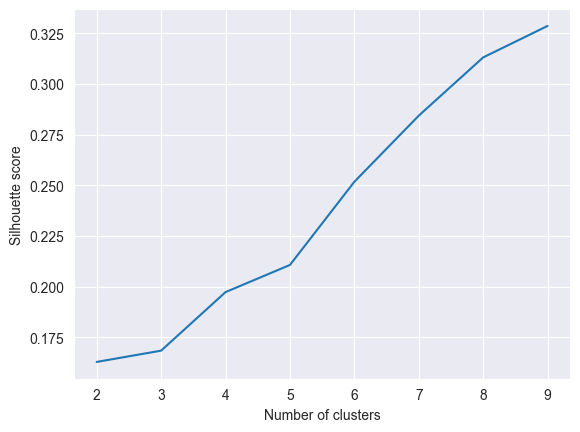


Done!


In [21]:
personae_4, features_df, follow = run_simulation_preprocessing(conn4, label='Simulation_4', feature_cols=features_cols)

Running Simulation_4...

Persona creation ...

persona
Persona_1    236
Persona_5    170
Persona_6    169
Persona_3    167
Persona_4    135
Persona_2    123
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 3.386654046839392e-133
conscientiousness: 6.8211618035854e-70
extroversion: 3.1349622379837405e-99
agreeableness: 1.0584187252945227e-67
neuroticism: 4.159344986844566e-121


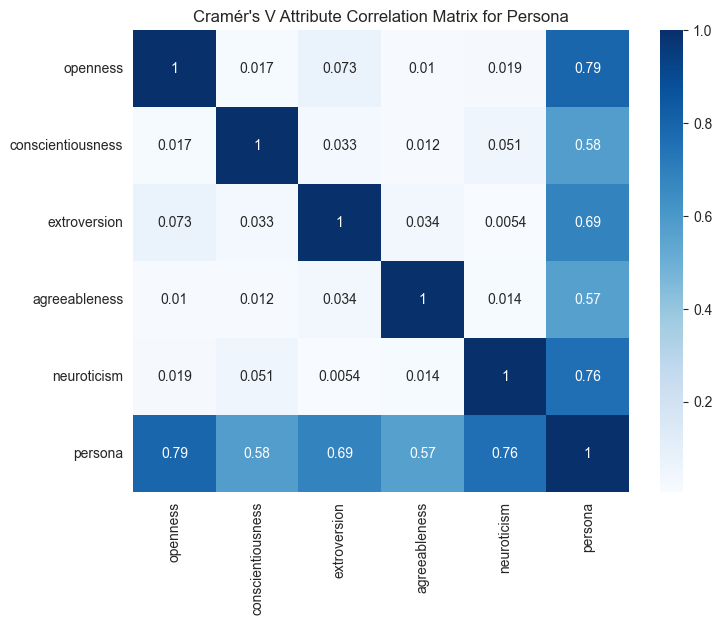

In [22]:
k_best = 6

description_4, persona_dict = cluster_persona_and_analyse(personae_4, features_df, k_best, label='Simulation_4', feature_cols=features_cols)

In [23]:
global_metrics_4, summary_4 = build_graph_and_analyse(follow, persona_dict, label='Simulation_4')

Running Simulation_4...

Graph creation ...

Number of nodes: 888
Number of edges: 8363
Number of connective components: 7
Components sizes: [882, 1, 1, 1, 1, 1, 1]
Number of nodes (LCC): 882
Number of edges (LCC): 8363

Global metrics ...

Mean degree: 18.84
Density: 0.0106
Diameter: 6
Avg. shortest path: 2.856
Modularity score: 0.183
Persona assortativity: -0.009410451607219691

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.2521
out_degree statistics: p = 0.2188
total_degree statistics: p = 0.2958
betweenness statistics: p = 0.5530
eigenvector statistics: p = 0.0994
pagerank statistics: p = 0.4112
kcore statistics: p = 0.2553


In [24]:
summary_4 = add_behavioral_features_to_persona_summary(conn4, summary_4, personae_4)
summary_4

Invalid unfollow action for users 8 -> 923: unfollow
Invalid unfollow action for users 8 -> 934: unfollow
Invalid unfollow action for users 10 -> 377: unfollow
Invalid unfollow action for users 12 -> 500: unfollow
Invalid unfollow action for users 12 -> 734: unfollow
Invalid unfollow action for users 12 -> 945: unfollow
Invalid unfollow action for users 17 -> 914: unfollow
Invalid unfollow action for users 21 -> 58: unfollow
Invalid unfollow action for users 21 -> 58: unfollow
Invalid unfollow action for users 21 -> 255: unfollow
Invalid unfollow action for users 21 -> 287: unfollow
Invalid unfollow action for users 21 -> 287: unfollow
Invalid unfollow action for users 21 -> 903: unfollow
Invalid unfollow action for users 21 -> 945: unfollow
Invalid unfollow action for users 27 -> 320: unfollow
Invalid unfollow action for users 27 -> 630: unfollow
Invalid unfollow action for users 29 -> 491: unfollow
Invalid unfollow action for users 29 -> 496: unfollow
Invalid unfollow action for user

C:\Users\magda\Studia\Master\src\social_graph\analysis.py:136: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  behavior_summary['lifespan_mean'].fillna(0, inplace=True)


,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio,Simulation,posts_per_day,avg_word_count,neutral_posts_ratio,negative_posts_ratio,survival_rate,lifespan_mean
persona,,,,,,,,,,,,,,,,
Persona_1,206,9.359223,8.466019,17.825243,0.001651,0.016475,0.001109,8.786408,0.977907,Simulation_4,2.371538,33.560934,0.033880,0.049453,0.864553,3.869936
Persona_2,107,10.149533,10.859813,21.009346,0.002232,0.020038,0.001203,10.280374,1.061132,Simulation_4,3.071579,33.268932,0.035636,0.047438,0.840948,4.463721
Persona_3,154,8.811688,9.642857,18.454545,0.001616,0.017999,0.001063,9.545455,0.937575,Simulation_4,2.667694,32.841971,0.035146,0.054470,0.864963,5.105525
Persona_4,119,9.344538,9.436975,18.781513,0.002347,0.016941,0.001132,8.327731,0.998802,Simulation_4,3.100000,32.644716,0.041781,0.060947,0.892109,3.927866
Persona_5,149,8.161074,8.020134,16.181208,0.001724,0.014893,0.000997,8.067114,0.879674,Simulation_4,2.570707,33.048192,0.029072,0.049959,0.881250,3.462717
Persona_6,147,11.319728,11.251701,22.571429,0.002800,0.020305,0.001332,9.802721,1.174794,Simulation_4,3.275858,33.252880,0.036566,0.046141,0.882214,4.187795


## Simulation 5

Running Simulation_5...

Data loading ...

Number of users: 1000
Total actions: 16799
Follow actions: 12468
Unfollow actions: 4331
Number of rounds: 61
Number of posts: 135434

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 25)

Searching best number of persona ...

k=2 silhouette=0.0816
k=3 silhouette=0.0961
k=4 silhouette=0.1382
k=5 silhouette=0.0972
k=6 silhouette=0.1022
k=7 silhouette=0.1138
k=8 silhouette=0.1054
k=9 silhouette=0.1170


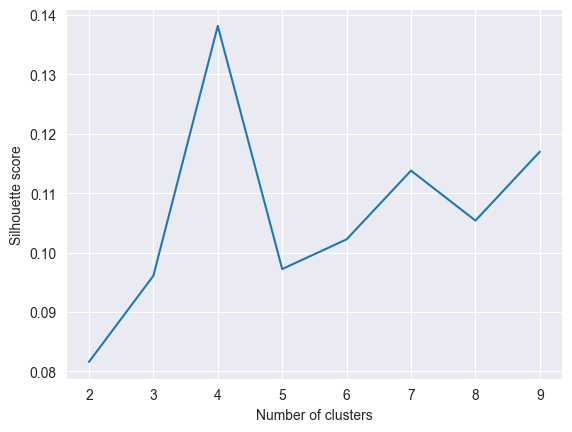


Done!


In [25]:
personae, features_df, follow = run_simulation_preprocessing(conn5, label='Simulation_5')

Running Simulation_5...

Persona creation ...

persona
Persona_4    195
Persona_3    186
Persona_2    178
Persona_5    171
Persona_1    138
Persona_6    132
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 1.0865997002032704e-64
conscientiousness: 4.03312440223404e-122
extroversion: 8.96511402734962e-81
agreeableness: 1.784811101351823e-108
neuroticism: 1.259301821379555e-63
age: 9.701914071122282e-42
profession: 0.001186118091210334


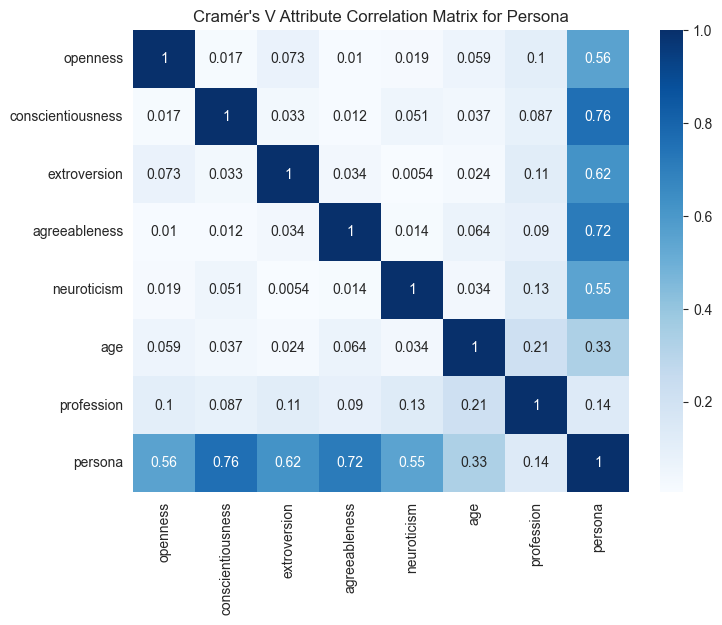

In [26]:
k_best = 6

description_5, persona_dict = cluster_persona_and_analyse(personae, features_df, k_best, label='Simulation_5')

In [27]:
global_metrics_5, summary_5 = build_graph_and_analyse(follow, persona_dict, label='Simulation_5')

Running Simulation_5...

Graph creation ...

Number of nodes: 903
Number of edges: 8214
Number of connective components: 7
Components sizes: [897, 1, 1, 1, 1, 1, 1]
Number of nodes (LCC): 897
Number of edges (LCC): 8214

Global metrics ...

Mean degree: 18.19
Density: 0.0101
Diameter: 6
Avg. shortest path: 2.910
Modularity score: 0.184
Persona assortativity: -0.01031502681361821

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.0023
out_degree statistics: p = 0.1619
total_degree statistics: p = 0.0272
betweenness statistics: p = 0.0002
eigenvector statistics: p = 0.0822
pagerank statistics: p = 0.0019
kcore statistics: p = 0.0828


In [28]:
summary_5 = add_behavioral_features_to_persona_summary(conn5, summary_5, personae)
summary_5

Invalid unfollow action for users 2 -> 494: unfollow
Invalid unfollow action for users 2 -> 513: unfollow
Invalid unfollow action for users 2 -> 783: unfollow
Invalid unfollow action for users 17 -> 274: unfollow
Invalid unfollow action for users 17 -> 397: unfollow
Invalid unfollow action for users 17 -> 485: unfollow
Invalid unfollow action for users 17 -> 889: unfollow
Invalid unfollow action for users 17 -> 892: unfollow
Invalid unfollow action for users 20 -> 231: unfollow
Invalid unfollow action for users 21 -> 925: unfollow
Invalid unfollow action for users 21 -> 945: unfollow
Invalid unfollow action for users 23 -> 475: unfollow
Invalid unfollow action for users 23 -> 676: unfollow
Invalid unfollow action for users 26 -> 970: unfollow
Invalid unfollow action for users 27 -> 500: unfollow
Invalid unfollow action for users 27 -> 743: unfollow
Invalid unfollow action for users 58 -> 216: unfollow
Invalid unfollow action for users 67 -> 781: unfollow
Invalid unfollow action for use

C:\Users\magda\Studia\Master\src\social_graph\analysis.py:136: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  behavior_summary['lifespan_mean'].fillna(0, inplace=True)


,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio,Simulation,posts_per_day,avg_word_count,neutral_posts_ratio,negative_posts_ratio,survival_rate,lifespan_mean
persona,,,,,,,,,,,,,,,,
Persona_1,123,10.609756,10.853659,21.463415,0.002160,0.020567,0.001240,10.227642,1.111987,Simulation_5,2.971610,33.132419,0.038954,0.048844,0.857744,4.913613
Persona_2,165,8.545455,8.375758,16.921212,0.001936,0.015302,0.001044,7.848485,0.936028,Simulation_5,2.566447,32.805717,0.045441,0.050128,0.890692,3.726934
Persona_3,171,7.005848,6.988304,13.994152,0.001374,0.013034,0.000896,7.345029,0.803325,Simulation_5,2.069979,33.237860,0.032537,0.041040,0.895124,3.711571
Persona_4,171,9.847953,10.052632,19.900585,0.002074,0.019259,0.001193,9.514620,1.070075,Simulation_5,2.916253,33.044453,0.041141,0.055781,0.858109,5.055464
Persona_5,149,10.993289,10.315436,21.308725,0.002556,0.019214,0.001295,9.617450,1.162025,Simulation_5,3.077582,33.611508,0.036152,0.047364,0.871328,4.496246
Persona_6,118,8.296610,8.864407,17.161017,0.001786,0.016541,0.001061,9.330508,0.951592,Simulation_5,2.429697,33.187138,0.027625,0.048134,0.843672,5.673345


## Analysis

### Global stability

In [29]:
global_metrics_summary = pd.concat([global_metrics_b1,
                                    global_metrics_b2,
                                    global_metrics_b3,
                                    global_metrics_3,
                                    global_metrics_4,
                                    global_metrics_5], axis=1)

global_metrics_summary

,Simulation_b1,Simulation_b2,Simulation_b3,Simulation_3,Simulation_4,Simulation_5
Metric,,,,,,
Mean degree,18.493243,19.202235,18.581369,18.493274,18.835586,18.192691
Density,0.010425,0.010740,0.010439,0.010378,0.010618,0.010085
Diameter,7.000000,7.000000,8.000000,6.000000,6.000000,6.000000
Avg. shortest path,2.878385,2.864391,2.896041,2.878621,2.856484,2.910075
Modularity,0.179283,0.175556,0.185098,0.174457,0.182722,0.183840
Persona assortativity,-0.000379,-0.006954,-0.006706,-0.005900,-0.009410,-0.010315


In [30]:
global_long = (
    global_metrics_summary
    .reset_index()
    .melt(
        id_vars='Metric',
        var_name='Simulation',
        value_name='Value'
    )
)

global_long.head()

,Metric,Simulation,Value
0,Mean degree,Simulation_b1,18.493243
1,Density,Simulation_b1,0.010425
2,Diameter,Simulation_b1,7.000000
3,Avg. shortest path,Simulation_b1,2.878385
4,Modularity,Simulation_b1,0.179283


In [31]:
global_stability = (
    global_long
    .groupby('Metric')['Value']
    .agg(['mean', 'std'])
)

global_stability['cv'] = global_stability['std'] / global_stability['mean']

global_stability

,mean,std,cv
Metric,,,
Avg. shortest path,2.880666,0.019801,0.006874
Density,0.010447,0.000224,0.021460
Diameter,6.666667,0.816497,0.122474
Mean degree,18.633066,0.346601,0.018601
Modularity,0.180159,0.004449,0.024697
Persona assortativity,-0.006611,0.003494,-0.528498


For each global metric (density, assortativity, diameter, etc.):

mean, std, coefficient of variation (CV = std / mean)

Interpretation:

- Low CV → stable across runs
- High CV → simulation sensitive to randomness

### Persona stability

In [32]:
summaries = [summary_b1, summary_b2, summary_b3, summary_3, summary_4, summary_5]
persona_tables = compare_persona_across_simulations(summaries, num_persona=6)

tab = persona_tables['Persona_1']
tab

Number of persona tables: 6


,Simulation_b1,Simulation_b2,Simulation_b3,Simulation_3,Simulation_4,Simulation_5
n_nodes,210,207,216,207,206,123
mean_in_degree,8.595238,8.144928,9.226852,9.227053,9.359223,10.609756
mean_out_degree,8.552381,8.700483,9.083333,8.666667,8.466019,10.853659
mean_total_degree,17.147619,16.845411,18.310185,17.89372,17.825243,21.463415
mean_betweenness,0.00164,0.001335,0.001964,0.001716,0.001651,0.00216
mean_eigenvector,0.016416,0.016126,0.017201,0.017308,0.016475,0.020567
mean_pagerank,0.001058,0.000984,0.001119,0.001132,0.001109,0.00124
mean_kcore,9.014286,9.338164,9.078704,9.183575,8.786408,10.227642
pagerank_ratio,0.930828,0.867942,0.993666,0.992924,0.977907,1.111987
posts_per_day,2.278265,2.27867,2.45095,2.367265,2.371538,2.97161


In [33]:
persona_stability = persona_metric_stability(persona_tables)
persona_stability

,persona,metric,mean,std,cv
0,Persona_1,n_nodes,194.000000,35.380315,0.182373
1,Persona_1,mean_in_degree,9.193842,0.835812,0.090910
2,Persona_1,mean_out_degree,9.053757,0.906860,0.100164
3,Persona_1,mean_total_degree,18.247599,1.662834,0.091126
4,Persona_1,mean_betweenness,0.001744,0.000286,0.164001
...,...,...,...,...,...
85,Persona_6,avg_word_count,33.204487,0.071777,0.002162
86,Persona_6,neutral_posts_ratio,0.033827,0.003474,0.102701
87,Persona_6,negative_posts_ratio,0.044960,0.003363,0.074811
88,Persona_6,survival_rate,0.866795,0.014758,0.017026


In [34]:
persona_stability[persona_stability['persona'] == 'Persona_2']

,persona,metric,mean,std,cv
15,Persona_2,n_nodes,118.000000,22.957933,0.194559
16,Persona_2,mean_in_degree,11.185434,1.873560,0.167500
17,Persona_2,mean_out_degree,10.586362,1.451515,0.137112
18,Persona_2,mean_total_degree,21.771796,3.264356,0.149935
19,Persona_2,mean_betweenness,0.002487,0.000412,0.165560
20,Persona_2,mean_eigenvector,0.019723,0.002636,0.133670
21,Persona_2,mean_pagerank,0.001298,0.000176,0.135310
22,Persona_2,mean_kcore,9.561653,1.065037,0.111386
23,Persona_2,pagerank_ratio,1.147520,0.150651,0.131284
24,Persona_2,posts_per_day,3.257188,0.599944,0.184191


In [35]:
persona_stability[persona_stability['persona'] == 'Persona_4']

,persona,metric,mean,std,cv
45,Persona_4,n_nodes,125.000000,22.447717,0.179582
46,Persona_4,mean_in_degree,8.674881,0.852972,0.098327
47,Persona_4,mean_out_degree,9.184265,0.525197,0.057184
48,Persona_4,mean_total_degree,17.859145,1.278342,0.071579
49,Persona_4,mean_betweenness,0.001986,0.000195,0.098003
50,Persona_4,mean_eigenvector,0.016499,0.001462,0.088623
51,Persona_4,mean_pagerank,0.001065,0.000085,0.079692
52,Persona_4,mean_kcore,8.368975,0.644188,0.076973
53,Persona_4,pagerank_ratio,0.942510,0.080129,0.085017
54,Persona_4,posts_per_day,2.892767,0.182554,0.063107


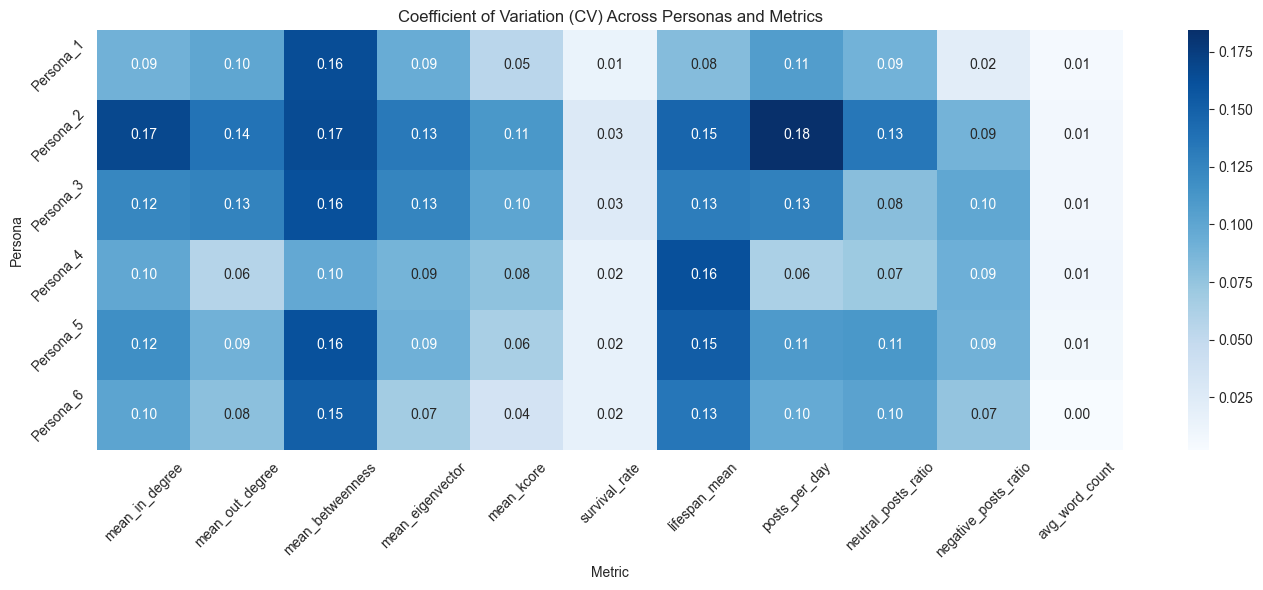

In [36]:
heatmap_data = persona_stability.pivot(
    index='persona',
    columns='metric',
    values='cv'
).drop(columns=['n_nodes'])

heatmap_data = heatmap_data[['mean_in_degree', 'mean_out_degree',  'mean_betweenness', 'mean_eigenvector', 'mean_kcore', 'survival_rate', 'lifespan_mean', 'posts_per_day', 'neutral_posts_ratio', 'negative_posts_ratio', 'avg_word_count']]


plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap='Blues'
)

plt.title('Coefficient of Variation (CV) Across Personas and Metrics')
plt.xlabel('Metric')
plt.xticks(rotation=45)
plt.ylabel('Persona')
plt.yticks(rotation=45)

plt.tight_layout()
plt.show()

In [37]:
ranking = persona_rank_stability(persona_tables)
rank_df = rank_consistency(ranking)
rank_df

mean  rank_std
persona   metric                                  
Persona_1 avg_word_count        2.000000  1.264911
          lifespan_mean         3.166667  1.329160
          mean_betweenness      4.666667  1.751190
          mean_eigenvector      3.500000  1.378405
          mean_in_degree        3.666667  1.366260
...                                  ...       ...
Persona_6 negative_posts_ratio  5.333333  0.816497
          neutral_posts_ratio   4.500000  1.378405
          pagerank_ratio        2.166667  0.983192
          posts_per_day         2.500000  1.516575
          survival_rate         3.000000  1.788854

[90 rows x 2 columns]

In [38]:
df = rank_df.reset_index()
df[df['metric'] == 'mean_betweenness']

,persona,metric,mean,rank_std
2,Persona_1,mean_betweenness,4.666667,1.751190
17,Persona_2,mean_betweenness,2.000000,1.264911
32,Persona_3,mean_betweenness,4.833333,1.471960
47,Persona_4,mean_betweenness,3.666667,1.032796
62,Persona_5,mean_betweenness,3.666667,1.505545
77,Persona_6,mean_betweenness,2.166667,1.471960


In [39]:
df = rank_df.reset_index()
df[df['metric'] == 'mean_kcore']

,persona,metric,mean,rank_std
5,Persona_1,mean_kcore,3.166667,1.169045
20,Persona_2,mean_kcore,2.333333,1.751190
35,Persona_3,mean_kcore,2.500000,1.870829
50,Persona_4,mean_kcore,5.166667,1.169045
65,Persona_5,mean_kcore,4.833333,1.471960
80,Persona_6,mean_kcore,3.000000,0.894427


In [40]:
df = rank_df.reset_index()
df[df['metric'] == 'survival_rate']

,persona,metric,mean,rank_std
14,Persona_1,survival_rate,3.333333,1.861899
29,Persona_2,survival_rate,4.500000,1.643168
44,Persona_3,survival_rate,3.833333,2.316607
59,Persona_4,survival_rate,2.666667,1.211060
74,Persona_5,survival_rate,3.666667,1.505545
89,Persona_6,survival_rate,3.000000,1.788854


B. Persona stability across simulations (key for you)

For each persona × metric:

- mean across simulations
- std across simulations
- rank stability (does Persona_1 always rank highest?)

Very important insight -
If persona effects are real, you should see:

- same persona ordering across simulations
- similar gaps between personae

If it’s noise:

- rankings flip
- gaps collapse

## Representative simulation analysis

Example simulation to describe in the report.

***Simulation b1*** - some differences between personae position in network structure are observed.

We do EDA and null model validation on it.

### EDA

In [41]:
# create graph
G, G_lcc = create_graph(followb1)

nx.set_node_attributes(G, persona_dict, "persona")
nx.set_node_attributes(G_lcc, persona_dict, "persona")

Number of nodes: 888
Number of edges: 8211
Number of connective components: 8
Components sizes: [880, 1, 1, 1, 1, 1, 1, 2]
Number of nodes (LCC): 880
Number of edges (LCC): 8210


In [42]:
users = pd.read_sql("SELECT * FROM user_mgmt", connb1)
users.drop([0], inplace=True)
users.head()

,id,username,email,password,user_type,leaning,age,oe,co,ex,...,frecsys_type,round_actions,gender,nationality,toxicity,is_page,left_on,daily_activity_level,profession,activity_profile
1,2,CynthiaSchwartz,CynthiaSchwartz@ysocial.it,CynthiaSchwartz,llama3.2:latest,democrat,27,consistent/cautious,efficient/organized,solitary/reserved,...,CommonNeighbors,10,female,American,low,0,None,1,Textile Worker,Always On
2,3,WayneHancock,WayneHancock@ysocial.it,WayneHancock,llama3.2:latest,democrat,57,inventive/curious,efficient/organized,outgoing/energetic,...,CommonNeighbors,3,male,American,low,0,None,5,Miner,Coffee Break User
3,4,HeatherTucker,HeatherTucker@ysocial.it,HeatherTucker,llama3.2:latest,democrat,16,inventive/curious,extravagant/careless,outgoing/energetic,...,CommonNeighbors,3,female,American,low,0,None,3,Student,Coffee Break User
4,5,JuanBrown,JuanBrown@ysocial.it,JuanBrown,llama3.2:latest,democrat,62,consistent/cautious,extravagant/careless,solitary/reserved,...,CommonNeighbors,3,male,American,low,0,None,2,Military Officer,Coffee Break User
5,6,JohnStark,JohnStark@ysocial.it,JohnStark,llama3.2:latest,democrat,52,consistent/cautious,extravagant/careless,solitary/reserved,...,CommonNeighbors,10,male,American,low,0,None,2,Tutor,Always On


In [43]:
users[['daily_activity_level']].value_counts()

daily_activity_level
1                       374
2                       291
3                       203
4                       105
5                        27
Name: count, dtype: int64

In [44]:
users[['profession']].value_counts()

profession      
Student             150
Clown                33
Textile Worker       28
Factory Worker       21
Military Officer     19
                   ... 
Dog Walker            2
Fortune Teller        1
Busker                1
Pharmacist            1
Photographer          1
Name: count, Length: 121, dtype: int64

In [45]:
users[['activity_profile']].value_counts()

activity_profile 
Coffee Break User    411
Community Builder    395
Always On            194
Name: count, dtype: int64

Agents:
- leaning: 100% democrat
- education level: 100% master
- each of 5 personality features has distribution approximately 50%/50%
- 100% English
- 100% American
- gender: 519 female, 481 male
- activity profile: 40% coffee break users, 40% community builder, 20% always on

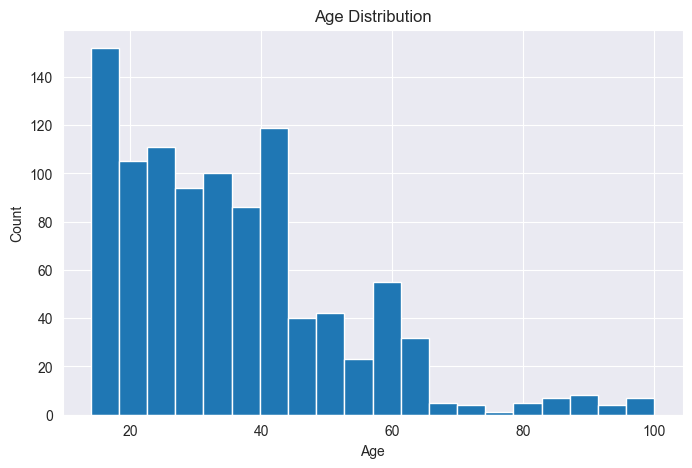

In [46]:
plt.figure(figsize=[8,5])
plt.hist(users[['age']], bins=20)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

In [47]:
degree = [dict(G.degree()).get(n, 0) for n in G.nodes()]
degree.sort(reverse=True)
degree[:10]

[225, 214, 213, 199, 189, 181, 174, 170, 166, 165]

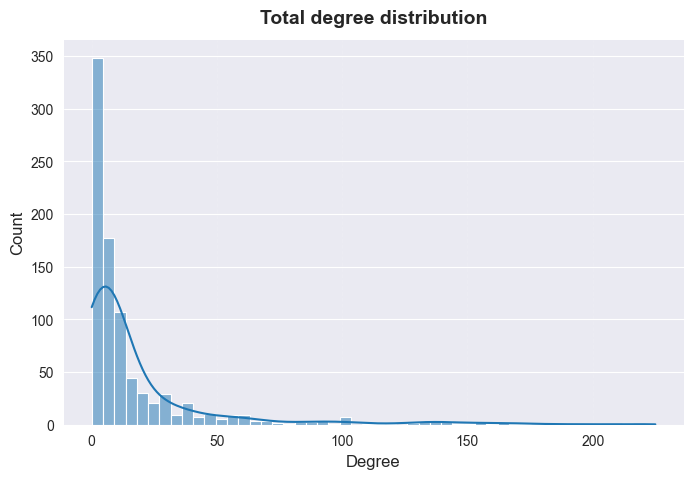

In [48]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
sns.histplot([dict(G.degree()).get(n, 0) for n in G.nodes()], bins=50, kde=True, ax=ax)
ax.set_title("Total degree distribution", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Degree", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.1)
sns.despine(left=True, bottom=True)
plt.show()

In [49]:
personaeb1.head()

,id,openness,conscientiousness,extroversion,agreeableness,neuroticism,age,profession,gender,leaning,education_level,persona
1,2,consistent/cautious,efficient/organized,solitary/reserved,friendly/compassionate,resilient/confident,young,Skilled_Trades,female,democrat,master,Persona_3
2,3,inventive/curious,efficient/organized,outgoing/energetic,friendly/compassionate,sensitive/nervous,old,Skilled_Trades,male,democrat,master,Persona_1
3,4,inventive/curious,extravagant/careless,outgoing/energetic,critical/judgmental,sensitive/nervous,young,Science_Academia,female,democrat,master,Persona_4
4,5,consistent/cautious,extravagant/careless,solitary/reserved,critical/judgmental,resilient/confident,old,Security,male,democrat,master,Persona_3
5,6,consistent/cautious,extravagant/careless,solitary/reserved,friendly/compassionate,sensitive/nervous,old,Science_Academia,male,democrat,master,Persona_5


In [50]:
personaeb1[['profession']].value_counts()

profession       
Science_Academia     232
Law_Finance_Admin    131
Retail_Service       130
Skilled_Trades       113
Arts_Media            88
Technology            73
Security              66
Sport                 40
Healthcare            38
Transport             37
Agriculture           28
Alternative           24
Name: count, dtype: int64

#### Mean degree over time

In [51]:
from collections import defaultdict, Counter

def group_nodes_by_persona(G):
    persona_groups = defaultdict(list)

    for node, data in G.nodes(data=True):
        persona = data.get("persona")
        persona_groups[persona].append(node)

    return persona_groups

In [52]:
def plot_degree_over_time(follow_df, persona_dict, round_step=24):
    """
    Mean degree analysis for personas groups over time. Generates plots.
    :param follow_df: follow table already merged with personas.
    """
    max_round = follow_df['round'].max()

    round_iter = round_step
    degree_daily = []

    while round_iter <= max_round:
        follow_r = follow_df[follow_df['round'] <= round_iter]

        G, G_lcc = create_graph(follow_r)
        nx.set_node_attributes(G, persona_dict, "persona")

        persona_groups = group_nodes_by_persona(G)
        persona_degree = {}

        for persona, nodes in persona_groups.items():

            degrees = [G.degree(n) for n in nodes]
            persona_degree[persona] = sum(degrees) / len(degrees) if degrees else 0

        df = pd.DataFrame(
            list(persona_degree.items()),
            columns=['persona', 'mean_degree']
        )

        df['day'] = round_iter // 24

        degree_daily.append(df)

        round_iter += round_step

    degree_daily = pd.concat(degree_daily, ignore_index=True)

    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=degree_daily,
        x='day',
        y='mean_degree',
        hue='persona'
    )
    plt.title('Mean degree over time')
    plt.show()

In [ ]:
plot_degree_over_time(followb1, persona_dict)

Number of nodes: 140
Number of edges: 117
Number of connective components: 36
Components sizes: [8, 10, 1, 6, 45, 2, 2, 9, 1, 2, 4, 1, 2, 2, 4, 1, 2, 1, 1, 2, 2, 3, 2, 5, 1, 1, 2, 3, 2, 2, 2, 2, 2, 2, 1, 2]
Number of nodes (LCC): 45
Number of edges (LCC): 48
Number of nodes: 235
Number of edges: 294
Number of connective components: 27
Components sizes: [189, 1, 4, 1, 1, 2, 3, 2, 1, 2, 2, 2, 2, 2, 2, 1, 3, 1, 1, 1, 2, 1, 1, 2, 2, 2, 2]
Number of nodes (LCC): 189
Number of edges (LCC): 273
Number of nodes: 306
Number of edges: 480
Number of connective components: 31
Components sizes: [250, 1, 4, 1, 1, 3, 2, 4, 1, 3, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 1, 1, 2, 2, 2, 2, 3, 2, 2, 2, 1]
Number of nodes (LCC): 250
Number of edges (LCC): 453
Number of nodes: 367
Number of edges: 670
Number of connective components: 37
Components sizes: [297, 1, 6, 1, 2, 2, 1, 3, 2, 2, 2, 2, 2, 1, 2, 1, 1, 3, 1, 1, 2, 2, 4, 3, 2, 2, 2, 1, 2, 1, 1, 2, 2, 2, 2, 2, 2]
Number of nodes (LCC): 297
Number of edges (LCC): 6

### Null model validation

In [50]:
G, G_lcc = create_graph(followb1)

nx.set_node_attributes(G_lcc, persona_dict, "persona")

Number of nodes: 888
Number of edges: 8211
Number of connective components: 8
Components sizes: [880, 1, 1, 1, 1, 1, 1, 2]
Number of nodes (LCC): 880
Number of edges (LCC): 8210


In [51]:
summary = summary_b1.drop(['Simulation'], axis=1, inplace=False)

Create null distribution by persona labels permutations.

In [52]:
null_distributions = persona_permutation_test(G_lcc, summary, n_perm=500)

p-values and z-scores for observed values vs. null distribution values.

In [53]:
p_values = permutation_pvalues(summary, null_distributions) # set a seed in future!!!
p_values

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio,posts_per_day,avg_word_count,neutral_posts_ratio,negative_posts_ratio,survival_rate,lifespan_mean
persona,,,,,,,,,,,,,,,
Persona_1,0.001996,0.666667,0.734531,0.702595,0.798403,0.648703,0.688623,0.433134,0.688623,1.0,1.0,1.0,1.0,1.0,1.0
Persona_2,1.000000,0.025948,0.085828,0.039920,0.033932,0.053892,0.027944,0.133733,0.027944,1.0,1.0,1.0,1.0,1.0,1.0
Persona_3,1.000000,0.415170,0.225549,0.327345,0.516966,0.267465,0.415170,0.083832,0.415170,1.0,1.0,1.0,1.0,1.0,1.0
Persona_4,1.000000,0.772455,0.786427,0.780439,0.632735,0.852295,0.768463,0.982036,0.768463,1.0,1.0,1.0,1.0,1.0,1.0
Persona_5,1.000000,0.732535,0.828343,0.780439,0.700599,0.786427,0.700599,0.862275,0.700599,1.0,1.0,1.0,1.0,1.0,1.0
Persona_6,0.001996,0.395210,0.271457,0.345309,0.221557,0.363273,0.429142,0.465070,0.429142,1.0,1.0,1.0,1.0,1.0,1.0


In [54]:
z_scores = permutation_zscores(summary, null_distributions)
z_scores

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio,posts_per_day,avg_word_count,neutral_posts_ratio,negative_posts_ratio,survival_rate,lifespan_mean
persona,,,,,,,,,,,,,,,
Persona_1,0.0,-0.454100,-0.633881,-0.538799,-0.890215,-0.398204,-0.483541,0.135698,-0.483541,NaN,NaN,NaN,NaN,NaN,NaN
Persona_2,0.0,2.125757,1.513259,1.887883,2.041759,1.751959,2.102656,1.174078,2.102656,NaN,NaN,NaN,NaN,NaN,NaN
Persona_3,0.0,0.160808,0.742163,0.416645,-0.091415,0.607120,0.173373,1.395135,0.173373,NaN,NaN,NaN,NaN,NaN,NaN
Persona_4,0.0,-0.682400,-0.759658,-0.727868,-0.331229,-1.060115,-0.653009,-1.942149,-0.653009,NaN,NaN,NaN,NaN,NaN,NaN
Persona_5,0.0,-0.639467,-0.879079,-0.753488,-0.594185,-0.801371,-0.545603,-1.048740,-0.545603,NaN,NaN,NaN,NaN,NaN,NaN
Persona_6,0.0,0.201830,0.597011,0.376878,0.815512,0.351937,0.150141,0.080778,0.150141,NaN,NaN,NaN,NaN,NaN,NaN


Interpretation:

| z value | Interpretation                     |
|---|------------------------------------|
| < 0.5 | negligible - essentially random    |
| 0.5–1 | weak - small systematic effect     |
| 1–2 | moderate - meaningful structure    |
| > 2 | strong - clear deviation from null |